# SwiGLU（Switched Gated Linear Unit），
- 这是现代大语言模型（如 LLaMA、PaLM、Qwen 等）中最常用的前馈网络（FFN）激活函数之一。

## 一、SwiGLU 的数学定义
SwiGLU 是 GLU（Gated Linear Unit） 变体家族的一员，使用 Swish（SiLU） 作为门控激活函数。

### 公式
SwiGLU(x,W,V,b,c)=Swish(xW+b)⊗(xV+c) 
其中：
- x∈$R^{d_model}$ ：输入向量
- W,V∈R^{ d_model×d_ffn}：两个独立的投影矩阵
- b,c∈R^{d_ffn}：偏置项（通常省略）
- Swish(z)=z⋅σ(z)=z ⋅ $\frac{1}{1+e^{-z}}$（也称为 SiLU）
- ⊗ ：逐元素乘法（Hadamard product）

### 在 Transformer FFN 中的完整形式
$FFN_{SwiGLU}(x)=(Swish(xW)⊗xV)W_2 $
 
其中：
- $W ∈ R^{d×\frac{2}{3}d_{ffn}}$
- $V ∈ R^{d×\frac{2}{3}d_{ffn}}$
- $W_2 ∈ R^{\frac{2}{3}d_{ffn} × d}$
  
注意：为了保持参数量与标准 FFN 相当，SwiGLU 的中间维度通常设为 $\frac{2}{3} × 4d = \frac{8}{3}d$ （而非 4d ），因为有两个投影矩阵 W  和 V 。


## 直观理解：门控机制
SwiGLU 的核心思想是 "门控" —— 用一部分输入决定另一部分输入的通过程度。


In [ ]:
标准 FFN (ReLU/GELU):        SwiGLU:
                             
    x ──→ Linear ──→ ReLU ──→ Linear ──→ output
         (d×4d)    (激活)    (4d×d)
                             
    x ──→ Linear ──→ Swish ──┐
         (d×8d/3)   (门控)   ├──⊗──→ Linear ──→ output
    x ──→ Linear ────────────┘      (8d/3×d)
         (d×8d/3)   (值)

### 类比：想象一个水龙头系统
- <font color='red'>Swish 分支</font>：控制水流大小的阀门（门控）
- <font color='red'>Linear 分支</font>：实际的水流（值）
- <font color='red'>⊗（逐元素乘）</font>：阀门调节后的实际出水

## 三、SwiGLU 的家族关系

In [ ]:
GLU (Gated Linear Unit) 家族
│
├── GLU (原始):    σ(xW + b) ⊗ (xV + c)          ← 用 Sigmoid 门控
├── Bilinear:      (xW + b) ⊗ (xV + c)            ← 无激活门控
├── ReGLU:         ReLU(xW + b) ⊗ (xV + c)        ← ReLU 门控
├── GEGLU:         GELU(xW + b) ⊗ (xV + c)       ← GELU 门控
└── SwiGLU:        Swish(xW + b) ⊗ (xV + c)        ← Swish/SiLU 门控 ★

### 为什么选 Swish？
- Swish 是 自门控 激活函数：Swish(x)=x⋅σ(x) 
- 它结合了线性和非线性特性，在深层网络中表现更稳定
- 相比 ReLU，Swish 在负数区域有平滑的梯度，避免"神经元死亡"

## 四、具体数值例子

假设：
- 输入维度 d=4 
- 中间维度 d ffn = \frac{2}{3}×4×4= \frac{32}{3}≈8 （取整为 8）
##### 输入
x=[1.0,0.5,−0.5,2.0] 



In [2]:
from IPython.display import Image

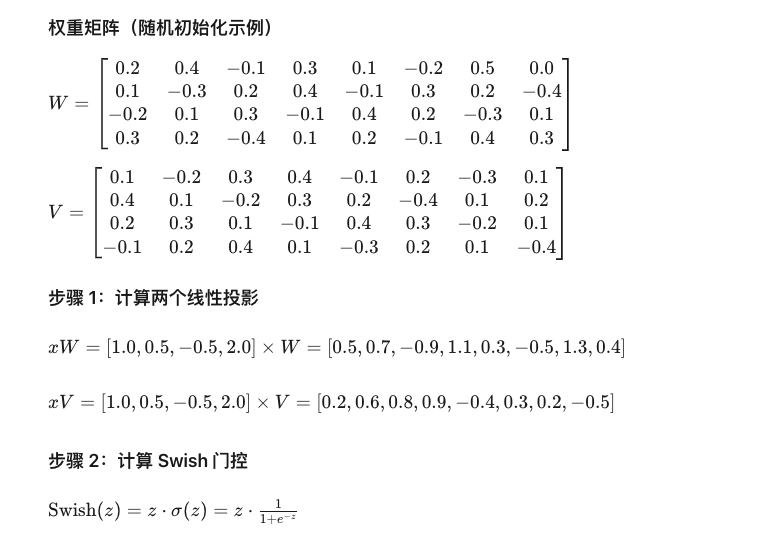

In [3]:
Image(filename='./SwiGLU.png')

逐元素计算：

| z  | σ(z) |  Swish(z) = z ⋅ σ(z) |
| ---- | ----------- | ------------------------------------- |
| 0.5  | 0.622       | 0.311                                 |
| 0.7  | 0.668       | 0.468                                 |
| -0.9 | 0.289       | -0.260                                |
| 1.1  | 0.750       | 0.825                                 |
| 0.3  | 0.574       | 0.172                                 |
| -0.5 | 0.378       | -0.189                                |
| 1.3  | 0.786       | 1.022                                 |
| 0.4  | 0.599       | 0.240                                 |


所以：
Swish(xW)=[0.311,0.468,−0.260,0.825,0.172,−0.189,1.022,0.240] 

## 步骤 3：门控乘法（逐元素）
gate=Swish(xW)⊗xV 

| Swish  | xV   | 乘积         |
| ------ | ---- | ---------- |
| 0.311  | 0.2  | **0.062**  |
| 0.468  | 0.6  | **0.281**  |
| -0.260 | 0.8  | **-0.208** |
| 0.825  | 0.9  | **0.743**  |
| 0.172  | -0.4 | **-0.069** |
| -0.189 | 0.3  | **-0.057** |
| 1.022  | 0.2  | **0.204**  |
| 0.240  | -0.5 | **-0.120** |

gate=[0.062,0.281,−0.208,0.743,−0.069,−0.057,0.204,−0.120] 

### 步骤 4：输出投影
$ W_2 ∈ R ^ 8×4 $
  
output=$gate × W_2$=[0.35,−0.12,0.48,0.21] 

## 五、SwiGLU vs 其他 FFN 的对比



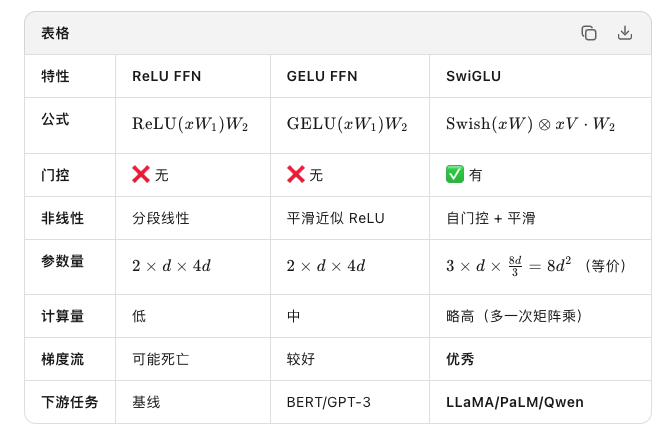

In [4]:
Image(filename='./SwiGLUvs.png')

## 六、在 LLaMA 中的实际应用
LLaMA 的 FFN 层使用 SwiGLU，配置如下：

In [ ]:
# LLaMA-7B 的 FFN 配置
hidden_size = 4096          # d_model
intermediate_size = 11008   # ≈ 2/3 × 4 × 4096 = 10922.67，取整

# 实际计算
# W_gate: 4096 × 11008
# W_up:   4096 × 11008  
# W_down: 11008 × 4096

# 参数量: 3 × 4096 × 11008 ≈ 135M (每层)

PyTorch 伪代码：

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SwiGLU(nn.Module):
    def __init__(self, dim: int, hidden_dim: int = None):
        super().__init__()
        if hidden_dim is None:
            # LLaMA 风格: 2/3 * 4 * dim
            hidden_dim = int(2/3 * 4 * dim)
        
        self.w_gate = nn.Linear(dim, hidden_dim, bias=False)  # 门控投影
        self.w_up   = nn.Linear(dim, hidden_dim, bias=False)  # 值投影
        self.w_down = nn.Linear(hidden_dim, dim, bias=False)  # 输出投影
    
    def forward(self, x):
        # x: (batch, seq_len, dim)
        gate = F.silu(self.w_gate(x))   # Swish/SiLU 激活: x * sigmoid(x)
        up   = self.w_up(x)              # 值分支
        hidden = gate * up               # 逐元素乘法 (Hadamard product)
        return self.w_down(hidden)       # 投影回原始维度

# 使用示例
ffn = SwiGLU(dim=4096, hidden_dim=11008)
x = torch.randn(2, 128, 4096)  # (batch=2, seq_len=128, dim=4096)
output = ffn(x)  # (2, 128, 4096)

## 七、为什么 SwiGLU 效果更好？
1. <font color='red'>门控机制提供动态路由</font>：不同 token 可以激活不同的"专家"子空间
2. <font color='red'>Swish 的平滑性</font>：避免 ReLU 的硬截断，梯度更稳定
3. <font color='red'>双投影增加表达能力</font>：W  和 V  学习不同的特征变换
4. <font color='red'>更好的梯度流</font>：门控结构类似 LSTM 的门，缓解梯度消失

### 直观类比：
- 标准 FFN 像一个固定调音的音响（ReLU/GELU 统一处理所有频率）
- SwiGLU 像一个智能均衡器（门控决定哪些频段增强/衰减，适应不同音乐风格）
